In [ ]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv'


In [ ]:
#cargamos el dataset y mostramos las primeras filas
try:
    dfc_devoluciones = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(dfc_devoluciones.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {dfc_devoluciones.shape[0]}")
print(f"Columnas: {dfc_devoluciones.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(dfc_devoluciones.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(dfc_devoluciones.head())
print("\nUltimas 5 filas del dataset:")
display(dfc_devoluciones.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(dfc_devoluciones.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(dfc_devoluciones.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(dfc_devoluciones.describe(include='object'))



Dimensiones del dataset:
Filas: 8108
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom,1,12,2010,10,2,1,-6.96



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
8103,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,"14,397.00",United Kingdom,9,12,2011,9,4,1,-23.40
8104,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,"14,397.00",United Kingdom,9,12,2011,9,4,1,-9.13
8105,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,"15,311.00",United Kingdom,9,12,2011,11,4,1,-54.75
8106,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-1.25
8107,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,"17,315.00",United Kingdom,9,12,2011,11,4,1,-6.25



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     8108 non-null   object 
 1   StockCode     8108 non-null   object 
 2   Description   8108 non-null   object 
 3   Quantity      8108 non-null   int64  
 4   InvoiceDate   8108 non-null   object 
 5   UnitPrice     8108 non-null   float64
 6   CustomerID    7954 non-null   float64
 7   Country       8108 non-null   object 
 8   InvoiceDay    8108 non-null   int64  
 9   InvoiceMonth  8108 non-null   int64  
 10  InvoiceYear   8108 non-null   int64  
 11  InvoiceHour   8108 non-null   int64  
 12  DayOfWeek     8108 non-null   int64  
 13  IsUk          8108 non-null   int64  
 14  TotalPrice    8108 non-null   float64
dtypes: float64(3), int64(7), object(5)
memory usage: 950.3+ KB


None


Resumen estadístico del dataset:


,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"8,108.00","8,108.00","7,954.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00","8,108.00"
mean,-11.88,4.44,"15,005.88",14.88,7.28,"2,010.92",13.20,2.24,0.85,-24.11
std,123.50,8.89,"1,708.58",8.69,3.55,0.27,2.76,1.55,0.36,146.75
min,"-9,360.00",0.03,"12,352.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,"-6,539.40"
25%,-6.00,1.45,"13,534.00",7.00,4.00,"2,011.00",11.00,1.00,1.00,-15.81
50%,-2.00,2.89,"14,895.00",14.00,8.00,"2,011.00",13.00,2.00,1.00,-7.95
75%,-1.00,4.95,"16,422.00",22.00,10.00,"2,011.00",15.00,3.00,1.00,-3.25
max,-1.00,295.00,"18,282.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,-0.12



Resumen descriptivo del dataset:


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,8108,8108,8108,8108,8108
unique,3299,1863,1888,3244,28
top,C570867,22423,REGENCY CAKESTAND 3 TIER,2011-10-12 16:17:00,United Kingdom
freq,101,172,172,101,6891


In [ ]:
# Getting the number of rows in the dataframe
dfc_devoluciones.shape[0]

8108

# Preprocesado y transformación de datos




In [ ]:

import pandas as pd
import numpy as np

# Rangos exactos de tu proyecto
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_returns_for_rf(df, target_col='TotalPrice'):
    # Convertir a valor absoluto para predecir "Volumen de Devolución"
    df[target_col] = df[target_col].abs()

    # Asegurar formato fecha y agrupar por día
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_returns']

    # Rellenar los días sin devoluciones con ceros, para que al hacer lag_1 tome como referencia el día de antes (ya que si no se han hecho devoluciones en un día, tomaría como día anterior el último día en el que se realizó alguna devolución)
    df_daily.set_index('date', inplace=True)

    idx = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max())
    df_daily = df_daily.reindex(idx, fill_value=0)
    df_daily = df_daily.reset_index().rename(columns={'index': 'date'})

    # FEATURE ENGINEERING (Ingeniería de Características)
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # Variables de "Memoria" (Lags de devoluciones)
    df_daily['returns_lag_1'] = df_daily['daily_returns'].shift(1)
    df_daily['returns_lag_7'] = df_daily['daily_returns'].shift(7)

    # Medias Móviles
    df_daily['rolling_mean_7_returns'] = df_daily['daily_returns'].shift(1).rolling(window=7).mean()
    df_daily['rolling_mean_30_returns'] = df_daily['daily_returns'].shift(1).rolling(window=30).mean()

    # Tendencia
    df_daily['trend_1_vs_7_returns'] = df_daily['returns_lag_1'] - df_daily['returns_lag_7']

    df_daily.bfill(inplace=True) # Rellenamos los primeros días NaN

    # División de conjuntos (Train, Val, Test)
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy()

    print(f" ==== Reporte de Datos de DEVOLUCIONES: ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Test Final:    {len(df_test)} días")
    print(f"   - Días con 0 devoluciones detectados y rellenados: {(df_daily['daily_returns'] == 0).sum()}")

    return df_train, df_val, df_test

# Ejecutamos asumiendo que tu dataset de devoluciones está en dfc_devoluciones
df_train, df_val, df_test = preprocess_returns_for_rf(dfc_devoluciones, 'TotalPrice')



 ==== Reporte de Datos de DEVOLUCIONES: ====== 
   - Entrenamiento: 343 días
   - Test Final:    31 días
   - Días con 0 devoluciones detectados y rellenados: 72


 Modelo: RANDOM_FOREST



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

print("\n--- 2. ENTRENAMIENTO Y OPTIMIZACIÓN (GRID VS RANDOMIZED) ---")

# Definimos las columnas predictoras (X) y el objetivo (y)
features = ['month', 'day_of_month', 'day_of_week', 'is_weekend', 'returns_lag_1', 'returns_lag_7' ,'rolling_mean_7_returns','rolling_mean_30_returns', 'trend_1_vs_7_returns']
target = 'daily_returns'

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

# IMPLEMENTACIÓN EXTRA: Definimos el particionado temporal
tscv = TimeSeriesSplit(n_splits=3)

# Ampliamos un poco la malla para que el experimento de tiempos tenga sentido
# Total de combinaciones posibles = 4 * 4 * 3 * 3 = 144 combinaciones
param_grid_devoluciones = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2', 1.0],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [4, 8, 12]
}
rf = RandomForestRegressor(random_state=42)

# OPCIÓN 1: GridSearchCV (Fuerza Bruta)

#print(f"\n1. Iniciando GridSearchCV (Probando TODAS las 144 combinaciones)...")
#start_time_grid = time.time()

#grid_search = GridSearchCV(
#    estimator=rf,
#    param_grid=param_grid,
#    cv=tscv,
#    scoring='neg_root_mean_squared_error',
#    n_jobs=-1
#)
#grid_search.fit(X_train, y_train)
#grid_time = time.time() - start_time_grid

#print(f" -> Tiempo GridSearchCV: {grid_time:.2f} segundos")
#print(f" -> Mejores parámetros Grid: {grid_search.best_params_}")



# OPCIÓN 2: RandomizedSearchCV (Muestreo Inteligente)

print("\n2. Iniciando RandomizedSearchCV (Probando SOLO 40 combinaciones al azar)...")
start_time_random = time.time()

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_devoluciones,
    n_iter=40,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time_random

print(f" -> Tiempo RandomizedSearchCV: {random_time:.2f} segundos")
print(f" -> Mejores parámetros Randomized: {random_search.best_params_}")


# VEREDICTO FINAL Y SELECCIÓN DE MODELO

print(" RESUMEN DE LA OPTIMIZACIÓN")
#print(f"RandomizedSearchCV fue {grid_time/random_time:.1f} veces más rápido")
print("Por ello es que nos quedamos con RandomizedSearchCV")

# Guardamos el mejor modelo encontrado
best_rf_model = random_search.best_estimator_



--- 2. ENTRENAMIENTO Y OPTIMIZACIÓN (GRID VS RANDOMIZED) ---

2. Iniciando RandomizedSearchCV (Probando SOLO 40 combinaciones al azar)...
 -> Tiempo RandomizedSearchCV: 43.44 segundos
 -> Mejores parámetros Randomized: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'log2', 'max_depth': 5}
 RESUMEN DE LA OPTIMIZACIÓN
Por ello es que nos quedamos con RandomizedSearchCV



--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST (DEVOLUCIONES) ---
 Métricas para Random Forest Optimizado (Devoluciones):
   - MAE:  399.08  (Error medio en dinero devuelto)
   - RMSE: 524.18 (Sensible a grandes picos de devoluciones)
   - R2:   0.1899  (Capacidad predictiva 0 a 1)
---------------------------------------------


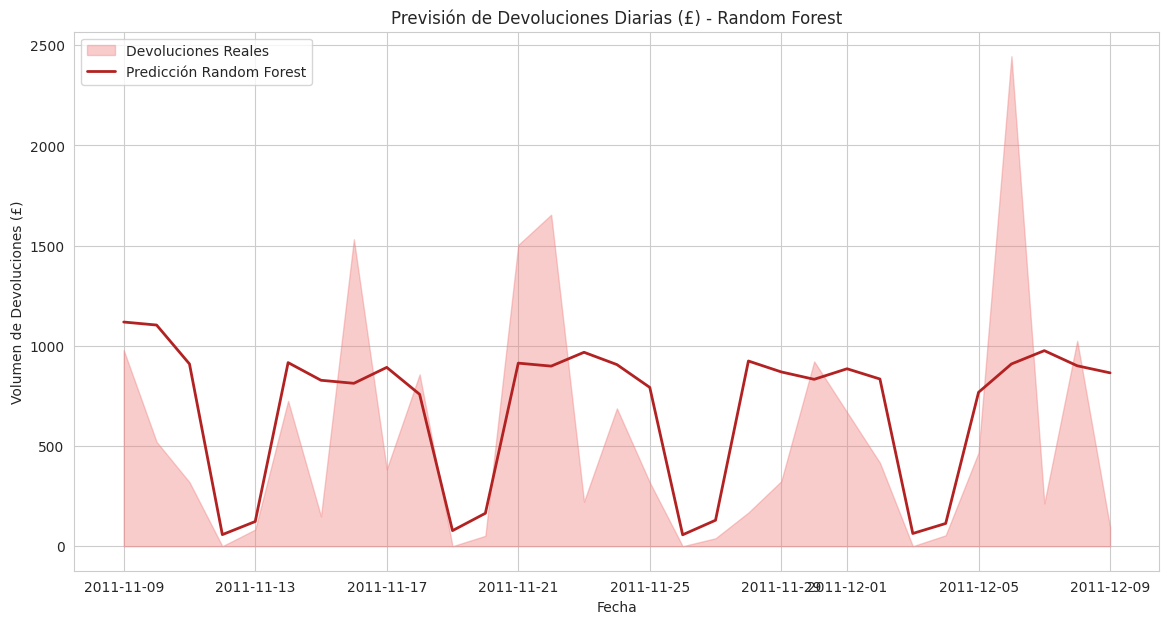

In [ ]:
print("\n--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST (DEVOLUCIONES) ---")

def evaluate_rf_test_returns(best_model, df_test, X_test, target_col):

    # Hacemos las predicciones
    preds = best_model.predict(X_test)

    # Preparamos el dataframe de evaluación
    df_eval = df_test.copy()
    df_eval['actual_returns'] = df_eval[target_col]
    df_eval['predicted_returns'] = preds
    df_eval['prediction_error'] = df_eval['actual_returns'] - df_eval['predicted_returns']

    # Calculamos métricas
    mae = mean_absolute_error(df_eval['actual_returns'], df_eval['predicted_returns'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual_returns'], df_eval['predicted_returns']))
    r2 = r2_score(df_eval['actual_returns'], df_eval['predicted_returns'])

    print(f" Métricas para Random Forest Optimizado (Devoluciones):")
    print(f"   - MAE:  {mae:,.2f}  (Error medio en dinero devuelto)")
    print(f"   - RMSE: {rmse:,.2f} (Sensible a grandes picos de devoluciones)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 45)

    # Gráfica de Devoluciones
    devoluciones_diarias = df_eval.set_index('date')[['actual_returns', 'predicted_returns']]

    plt.figure(figsize=(14, 7))
    plt.fill_between(devoluciones_diarias.index, devoluciones_diarias['actual_returns'], color="lightcoral", alpha=0.4, label='Devoluciones Reales')
    plt.plot(devoluciones_diarias.index, devoluciones_diarias['predicted_returns'], color="firebrick", lw=2, label='Predicción Random Forest')

    plt.title("Previsión de Devoluciones Diarias (£) - Random Forest")
    plt.xlabel("Fecha")
    plt.ylabel("Volumen de Devoluciones (£)")
    plt.legend()
    plt.show()

    return mae, rmse, df_eval

# Lanzamos la evaluación final
mae_rf_ret, rmse_rf_ret, df_eval_rf_ret = evaluate_rf_test_returns(best_rf_model, df_test, X_test, target)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print(" FASE FINAL: GENERACIÓN DE DATAFRAMES ")
print("="*80)

# PASO 1: GENERAR EL DATAFRAME GANADOR DE VENTAS (Sin la anomalía B2B)

preds_devoluciones = best_rf_model.predict(X_test)

df_devolu_eval = df_test.copy()
df_devolu_eval['actual_returns'] = df_devolu_eval['daily_returns'] # Tu target original
df_devolu_eval['predicted_returns'] = preds_devoluciones

# Aplicamos la Regla de Negocio: Excluir el pedido mayorista del 14 de Noviembre
fecha_anomala = '2011-11-14'
df_ventas_corregido = df_devolu_eval[df_devolu_eval['date'].astype(str) != fecha_anomala].copy()

ruta_drive = '/content/drive/MyDrive/TFM_Prediccion_Devolu_RandomForest.csv'

# 4. Guardar el DataFrame
df_ventas_corregido.to_csv(ruta_drive, index=False)


 FASE FINAL: GENERACIÓN DE DATAFRAMES 
